<a href="https://colab.research.google.com/github/jerovernay/IMC/blob/main/IMC_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Integrantes** \
Reynaldo Martín Peralta Recio, 428/22 \
Jeronimo Vernay, 313/24


# TP I - Trayectorias de Kepler y corrección relativista

Una corrección relativista para el problema de dos cuerpos de Kepler, sistema Sol-planeta, puede describirse en coordenadas polares con la ecuación:
$$
\ddot{u}(θ) + u(θ) - \frac{1}{α} - \delta u²(θ) = 0  
$$
Donde $u(θ) = \frac{1}{r(θ)}$, el Sol se encuentra en el origen, $α$ y $δ$ son constantes. El término con $δ$ es la corrección relativista.

1. Formular el problema como un sistema de orden uno de la forma $\dot{y} = f (θ, y)$. Observar que la variable independiente no es el tiempo sino ángulos en polares.

###Solucion:

Para formular el problema como un sistema de orden 1 de la forma $\dot{y} \,=\,f(\theta , y)$, debemos de definir un vector de estado con la variable independiente $θ$, pues la variable independiente deben de ser los angulos.

Sea:

$$\;y_1(\theta) \, = \, u(\theta) \, = \, \frac{1}{r (\theta)} \quad \text{y} \quad y_2(\theta) \, = \, \dot u(\theta) \quad ⇒ \quad y(\theta) \, = \, (y_1(\theta) \,,\, y_2(\theta)) \\[0.3cm]$$

Luego definimos el campo vectorial $\,f(\theta, y)\,$ al derivar sobre $\dot y: \\[0,2cm]$

$$\dot y \, =\, (\dot y_1\, , \, \dot y_2) \,  $$

Donde:

$$ \dot y_1 \, = \, y_2 $$
$$\dot y_2 \, = \, \ddot u \, = \, -u \, + \frac{1}{\alpha} \, \delta \, u^2 $$ $$ \dot y_2 \, = \, -y_1 \, +\, \frac{1}{\alpha} \, + \, \delta \, y_1^2 \\[0,3cm]$$

Por lo tanto:

$$\dot y \, =\, f(\theta, y)\, = \, (\dot y_1 \, , \,\dot y_2) \, = \, (\,y_2 \, , \,-y_1 \, +\, \frac{1}{\alpha} \, + \, \delta \, y_1^2\,) \\[0,3cm]$$

El estado del sistema queda definido por la inversa de la distancia radial ($\,y_1 = u(\theta)$) y su tasa de cambio respecto al ángulo ($y_2 = \dot{u}(\theta)$). Como el ángulo $\theta$ , la variable independiente, no aparece de forma explicita en las ecuaciones, obtenemos un sistema autónomo no lineal de primer orden.

&nbsp;

2. Resolver el problema de Kepler ($δ = 0$), con condiciones iniciales $r(0) = \frac{α}{1 + ϵ}$ y $\dot{r}(0) = 0$. Donde $ϵ$
es la excentricidad de la órbita: $0 ≤ ϵ < 1$ para orbitas cerradas, $ϵ ≥ 1$ para órbitas abiertas. La
condición $\dot{r}(0) = 0$ (velocidad radial cero) significa que medimos los ángulos a partir del perihelio
(punto más cercano al Sol). \
Graficar soluciones con $α = 1$ para distintos valores de $ϵ$. Observar que pasa cuando $θ > 2π$ (3 o
4 vueltas).

###Solucion:



<>:59: SyntaxWarning: invalid escape sequence '\e'
<>:63: SyntaxWarning: invalid escape sequence '\d'
<>:59: SyntaxWarning: invalid escape sequence '\e'
<>:63: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3231/4155281899.py:59: SyntaxWarning: invalid escape sequence '\e'
  ax.plot(solucion.t, r_res, label=f'Excentricidad $\epsilon={eps}$')
/tmp/ipykernel_3231/4155281899.py:63: SyntaxWarning: invalid escape sequence '\d'
  ax.set_title('Trayectorias de Kepler ($\delta=0$) para $\\theta > 2\pi$', va='bottom')


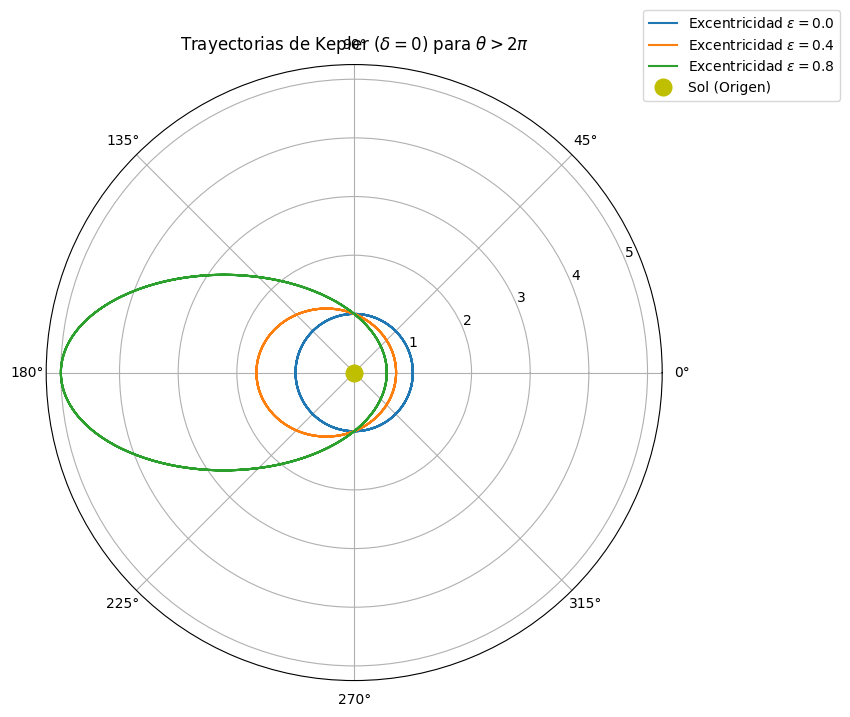

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ipywidgets import interact, FloatSlider

# --- 1. DEFINICIÓN ÚNICA DEL SISTEMA ---

def sistema_kepler(theta, y, alpha, delta):
    u, u_dot = y
    return [u_dot, -u + 1/alpha + delta * (u**2)]

# --- 2. FUNCIÓN DE APOYO PARA GRAFICAR ---

def resolver_y_graficar(epsilon, delta=0.0, alpha=1.0, vueltas=4): #Ojo con los deltas y alphas para el 3
    theta_span = (0, vueltas * 2 * np.pi)               # Vueltas
    theta_eval = np.linspace(theta_span[0], theta_span[1], 1000)

    # Condición inicial: u(0) = (1+e)/alpha, u_dot(0) = 0
    y0 = [(1 + epsilon) / alpha, 0.0]

    sol = solve_ivp(sistema_kepler, theta_span, y0, t_eval=theta_eval, args=(alpha, delta))
    return sol.t, 1/sol.y[0] # Retorna theta y r

# --- 3. GRÁFICO PARA EL INFORME (PUNTO 2) ---

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, projection='polar')

for e in [0.0, 0.4, 0.8]:
    theta, r = resolver_y_graficar(epsilon=e, delta=0.0)
    ax.plot(theta, r, label=f'$\epsilon={e}$')

ax.plot(0, 0, 'yo', markersize=12, label='Sol (Origen)')
ax.set_title("Órbitas clásicas con ($\delta=0$)")
ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.show()

###Es el mismo codigo pero el colab lo imprime mal

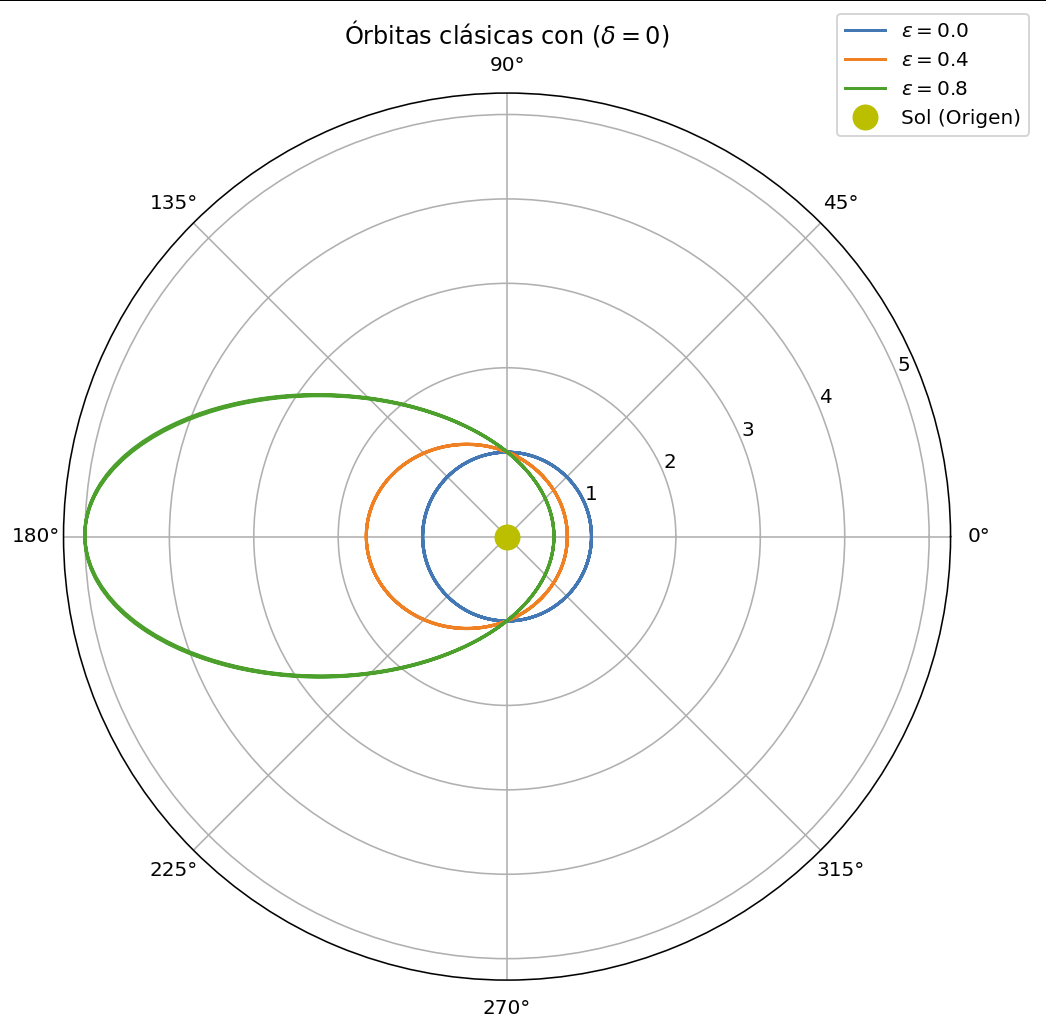

In [ ]:
# --- 4. Grafico interactivo (A mejorar)---

def widget_interactivo(epsilon):
    theta, r = resolver_y_graficar(epsilon=epsilon, delta=0.0)
    plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, projection='polar')
    ax.plot(theta, r)
    ax.set_title(f"Exploración: $\epsilon={epsilon}$")
    plt.show()

interact(widget_interactivo, epsilon=FloatSlider(min=0, max=0.9, step=0.05, value=0.5))

3. Resolver el problema relativista para $δ = 0.05$ en las mismas condiciones iniciales del ítem anterior
y comparar. \
El efecto se conoce como precesión del perihelio y las mediciones sobre la órbita de Mercurio fueron
utilizadas por Albert Einstein como evidencia experimental de la Teoría General de la Relatividad.